# Segmentación de Clientes — Euro Supermercados

Identifica **5 perfiles de negocio** a partir del comportamiento de compra:

| Perfil | Tickets/mes | Ticket (COP) | Meses activos | Descripción |
|--------|-------------|-------------|---------------|-------------|
| **Ballena** | Alto (>8) | Alto (>$200k) | Alto | Mini-mercados, compras mayoristas |
| **Cotidiano** | 2-8 | Medio ($50-150k) | Alto | Familia que merca regularmente |
| **Mensual** | ~1-2 | Medio | Moderado | Compra puntual 1 vez/mes |
| **Hormiga** | Alto | Bajo (<$30k) | Alto | Visitas frecuentes, compras pequeñas |
| **Esporádico** | Bajo | Variable | Bajo | Irregular, **no predecible** |

**Fuente de datos:** `data/processed/initial_sales_clean.parquet` (central del pipeline DVC).

**Módulos de `src/`:** `client_filters`, `patterns` (`compute_segmentation_features`, `label_clusters`), `config`, `data_io`.

---

## 1. Setup

In [2]:
import os
import sys
from pathlib import Path

os.chdir(Path("..").resolve())
sys.path.insert(0, "src")

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

from config import load_config, processed_path
from data_io import load_parquet, load_product_catalog, save_parquet
from client_filters import validate_client_ids
from patterns import compute_segmentation_features, filter_recent_clients, label_clusters

logging.basicConfig(level=logging.INFO, format="%(levelname)s - %(message)s")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

cfg = load_config("params.yaml")
clust_cfg = cfg["recommendations_clustering"]
seed = cfg["base"]["random_state"]
proc = processed_path(cfg)

# Colores fijos por segmento
SEGMENT_COLORS = {
    "ballena": "#e74c3c",     # rojo
    "cotidiano": "#2ecc71",   # verde
    "mensual": "#3498db",     # azul
    "hormiga": "#f39c12",     # naranja
    "esporadico": "#95a5a6",  # gris
}

print(f"Directorio: {os.getcwd()}")

Directorio: /Users/juandavidrincon/Documents/euro_nuevo_nov/euro


## 2. Carga y Validación de Datos

Filtros de cédula colombiana:
- Solo dígitos, longitud 6-10 (CC válida)
- Excluye IDs genéricos (111111, 999999, etc.) e IDs que empiezan en 0

In [3]:
sales_raw = load_parquet(proc / cfg["data"]["sales_file"], "Ventas brutas")
productos = load_product_catalog(proc / cfg["data"]["products_file"])

# Validar IDs
sales = validate_client_ids(sales_raw, id_col="id_client")

# Filtrar clientes con actividad reciente
months = clust_cfg["months_recent_activity"]
recent = filter_recent_clients(sales, months=months)

n_removed = sales_raw["id_client"].nunique() - sales["id_client"].nunique()
print(f"\nClientes válidos: {sales['id_client'].nunique():,} ({n_removed:,} eliminados por ID inválido)")
print(f"Clientes activos (últimos {months} meses): {recent['id_client'].nunique():,}")
print(f"Rango: {recent['date_sale'].min().date()} → {recent['date_sale'].max().date()}")

INFO - Ventas brutas cargado: 17584197 filas desde data/processed/initial_sales_clean.parquet
INFO - Catálogo cargado: 26534 productos únicos
INFO - Filtro de IDs: 17584197 -> 17575982 filas (8215 eliminadas, 0.0%)
INFO - Clientes últimos 1 meses (ref: 2026-03-09, corte: 2026-02-07): 125010



Clientes válidos: 267,983 (190 eliminados por ID inválido)
Clientes activos (últimos 1 meses): 125,010
Rango: 2025-09-10 → 2026-03-09


## 3. Features de Segmentación

Solo 3 features clave que separan los 5 perfiles:

| Feature | Qué mide | Separa |
|---------|----------|--------|
| `tickets_per_month` | Promedio de tickets por mes activo | Ballena/Hormiga (alto) vs Mensual (bajo) |
| `ticket_median` | Valor mediano del ticket (COP) | Ballena (alto) vs Hormiga (bajo) |
| `months_active_ratio` | Fracción de meses con compra | Esporádico (bajo) vs todos los demás |

In [4]:
# Calcular features para TODOS los clientes (incluidos esporádicos)
features = compute_segmentation_features(
    recent,
    amount_col="invoice_value_with_discount_and_without_iva",
)

print(f"\nFeatures para {len(features):,} clientes:")
features[["tickets_per_month", "ticket_median", "months_active_ratio"]].describe().round(1)

INFO - Features de segmentación: 125010 clientes, ventana=7 meses, features=6



Features para 125,010 clientes:


,tickets_per_month,ticket_median,months_active_ratio
count,125010.0,125010.0,125010.0
mean,2.1,3213784.0,0.6
std,1.8,12448822.2,0.3
min,1.0,126.0,0.1
25%,1.0,113229.8,0.3
50%,1.5,418099.2,0.6
75%,2.3,1729986.8,0.9
max,23.9,941047294.5,1.0


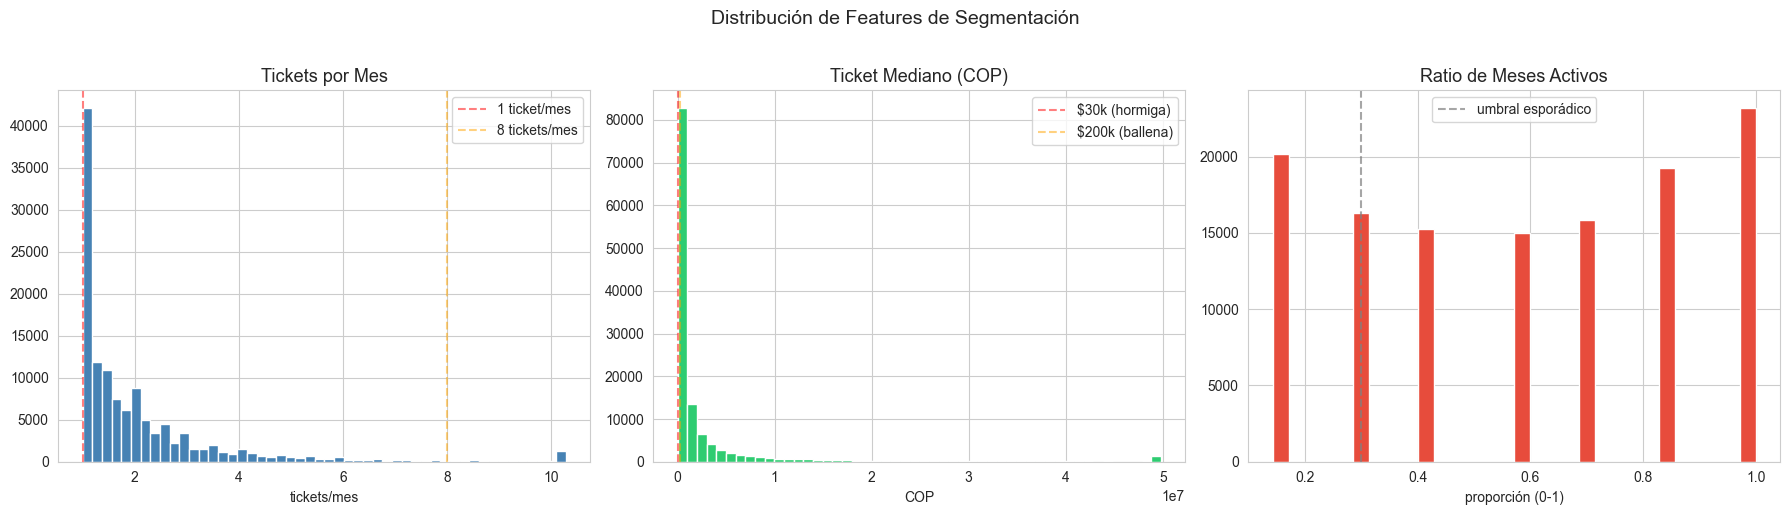

In [5]:
# Distribución de las 3 features clave
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features["tickets_per_month"].clip(upper=features["tickets_per_month"].quantile(0.99)).hist(
    bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Tickets por Mes", fontsize=13)
axes[0].set_xlabel("tickets/mes")
axes[0].axvline(1, color="red", linestyle="--", alpha=0.5, label="1 ticket/mes")
axes[0].axvline(8, color="orange", linestyle="--", alpha=0.5, label="8 tickets/mes")
axes[0].legend()

features["ticket_median"].clip(upper=features["ticket_median"].quantile(0.99)).hist(
    bins=50, ax=axes[1], color="#2ecc71", edgecolor="white")
axes[1].set_title("Ticket Mediano (COP)", fontsize=13)
axes[1].set_xlabel("COP")
axes[1].axvline(30000, color="red", linestyle="--", alpha=0.5, label="$30k (hormiga)")
axes[1].axvline(200000, color="orange", linestyle="--", alpha=0.5, label="$200k (ballena)")
axes[1].legend()

features["months_active_ratio"].hist(
    bins=30, ax=axes[2], color="#e74c3c", edgecolor="white")
axes[2].set_title("Ratio de Meses Activos", fontsize=13)
axes[2].set_xlabel("proporción (0-1)")
axes[2].axvline(0.3, color="gray", linestyle="--", alpha=0.7, label="umbral esporádico")
axes[2].legend()

plt.suptitle("Distribución de Features de Segmentación", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Clustering K-Means

- Log-transform en `ticket_median` (distribución sesgada)
- StandardScaler
- Selección de K: Codo + Silhouette

In [6]:
# Preparar features
feature_cols = clust_cfg["features_for_clustering"]
print(f"Features: {feature_cols}")

X = features[feature_cols].copy()
X = X.fillna(X.median())

# Log-transform en ticket_median (distribución sesgada)
X["ticket_median"] = np.log1p(X["ticket_median"].clip(lower=0))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Shape: {X_scaled.shape}")

Features: ['tickets_per_month', 'ticket_median', 'months_active_ratio']
Shape: (125010, 3)


  k=3 → silhouette=0.3549
  k=4 → silhouette=0.3518
  k=5 → silhouette=0.3211
  k=6 → silhouette=0.3455
  k=7 → silhouette=0.3125
  k=8 → silhouette=0.2957


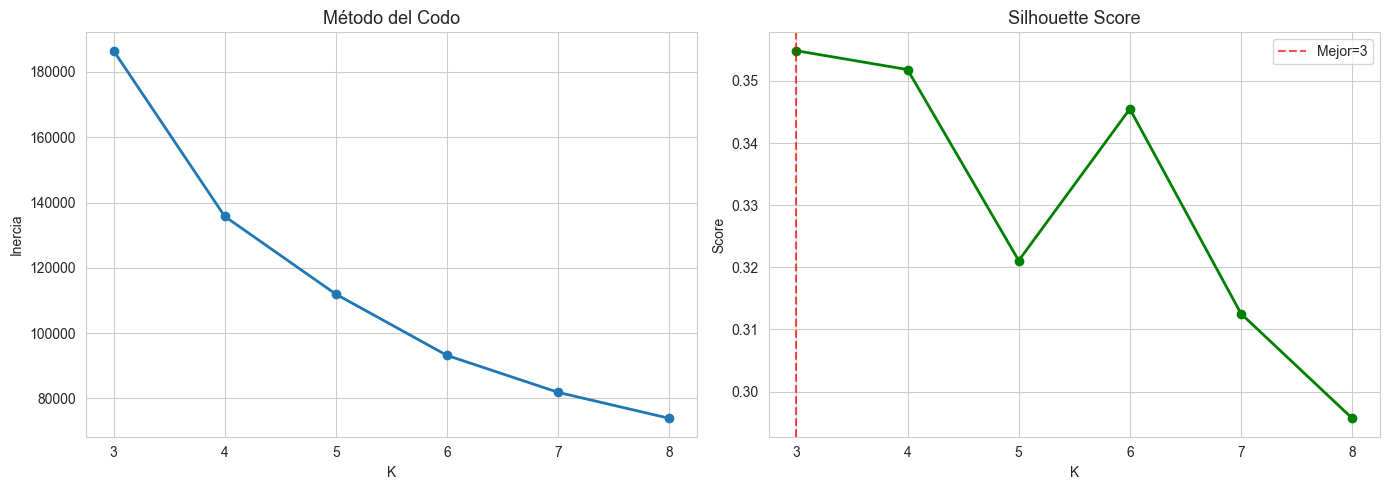


Mejor K según silhouette: 3
K configurado en params.yaml: 5


In [7]:
# Selección de K
k_range = range(3, 9)
inertias = []
silhouettes = []

sample_size = min(5000, len(X_scaled))
for k in k_range:
    km = KMeans(n_clusters=k, random_state=seed, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=sample_size)
    silhouettes.append(sil)
    print(f"  k={k} → silhouette={sil:.4f}")

best_k = list(k_range)[np.argmax(silhouettes)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(k_range, inertias, marker="o", linewidth=2)
ax1.set_title("Método del Codo", fontsize=13)
ax1.set_xlabel("K")
ax1.set_ylabel("Inercia")

ax2.plot(k_range, silhouettes, marker="o", color="green", linewidth=2)
ax2.axvline(best_k, color="red", linestyle="--", alpha=0.7, label=f"Mejor={best_k}")
ax2.set_title("Silhouette Score", fontsize=13)
ax2.set_xlabel("K")
ax2.set_ylabel("Score")
ax2.legend()

plt.tight_layout()
plt.show()
print(f"\nMejor K según silhouette: {best_k}")
print(f"K configurado en params.yaml: {clust_cfg['n_clusters']}")

In [8]:
# Entrenar K-Means
chosen_k = clust_cfg["n_clusters"] or best_k
print(f"K elegido: {chosen_k}")

kmeans = KMeans(n_clusters=chosen_k, random_state=seed, n_init="auto")
features = features.copy()
features["cluster"] = kmeans.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, features["cluster"], sample_size=sample_size)
print(f"Silhouette final: {sil_final:.4f}")

K elegido: 5
Silhouette final: 0.3269


In [9]:
# Asignar etiquetas de negocio automáticamente
features = label_clusters(features)

print("\nResumen de segmentos:")
summary = features.groupby(["segment", "segment_label"]).agg(
    clientes=("id_client", "count"),
    tickets_mes=("tickets_per_month", "mean"),
    ticket_mediano=("ticket_median", "mean"),
    meses_activos=("months_active_ratio", "mean"),
    prods_por_visita=("products_per_visit", "mean"),
).round(1)
display(summary)

INFO - Segmentos asignados:
            clientes  tickets_mes  ticket_mediano  meses_activos
segment                                                         
ballena        23620          2.2       8387607.6            0.9
cotidiano      32903          2.7        294388.0            0.9
esporadico     34359          1.3        120443.5            0.3
hormiga         4620          9.2        403448.6            1.0
mensual        29508          1.3       6369505.0            0.3



Resumen de segmentos:


,,clientes,tickets_mes,ticket_mediano,meses_activos,prods_por_visita
segment,segment_label,,,,,
ballena,Ballena (mini-mercado),23620,2.2,8387607.6,0.9,22.1
cotidiano,Cotidiano (familia),32903,2.7,294388.0,0.9,6.9
esporadico,Esporádico,34359,1.3,120443.5,0.3,3.8
hormiga,"Hormiga (frecuente, bajo monto)",4620,9.2,403448.6,1.0,7.2
mensual,Mensual,29508,1.3,6369505.0,0.3,17.3


## 5. Perfilamiento Visual de Segmentos

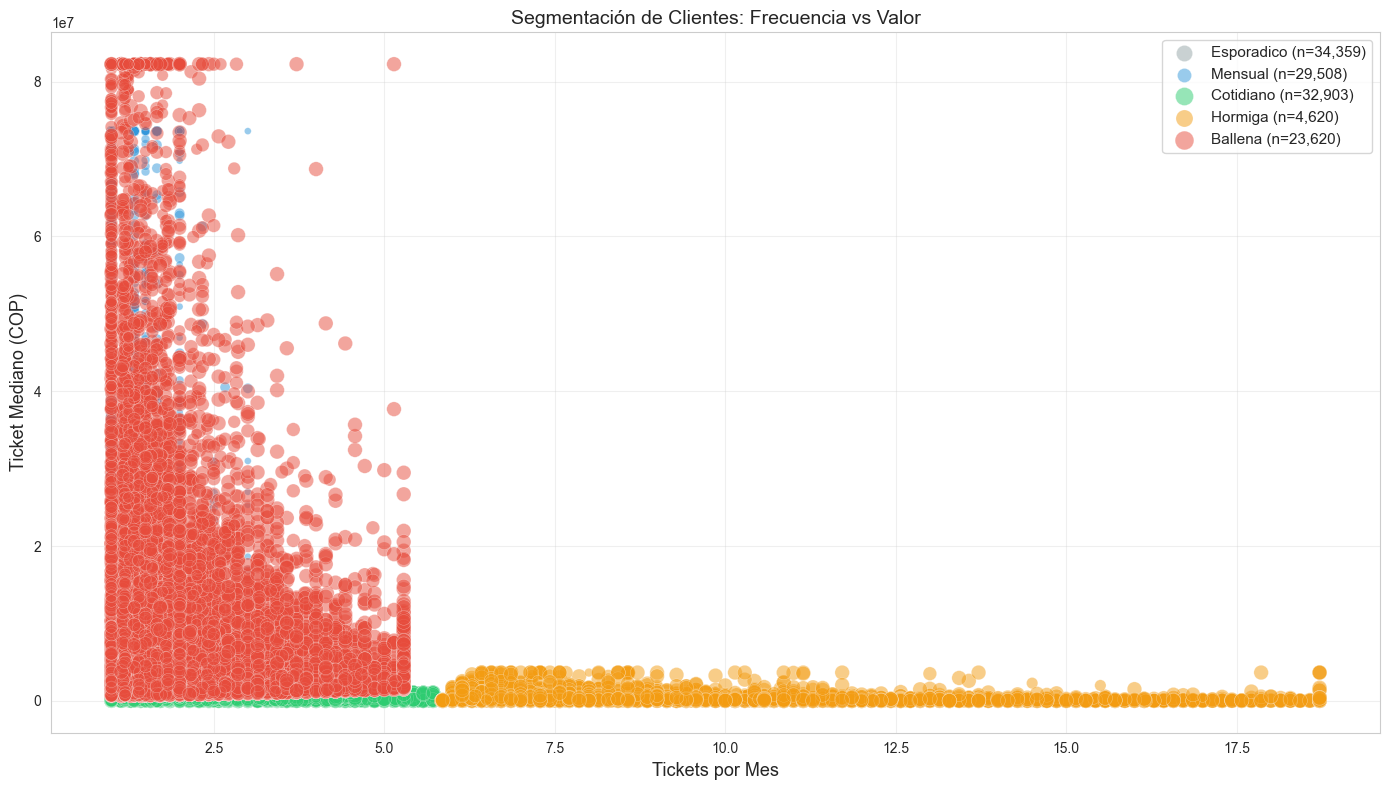

In [10]:
# Scatter principal: Tickets/mes vs Ticket mediano, tamaño = meses activos
fig, ax = plt.subplots(figsize=(14, 8))

for seg in ["esporadico", "mensual", "cotidiano", "hormiga", "ballena"]:
    mask = features["segment"] == seg
    if not mask.any():
        continue
    data = features[mask]
    ax.scatter(
        data["tickets_per_month"].clip(upper=data["tickets_per_month"].quantile(0.99)),
        data["ticket_median"].clip(upper=data["ticket_median"].quantile(0.99)),
        s=data["months_active_ratio"] * 100 + 10,
        c=SEGMENT_COLORS[seg],
        alpha=0.5,
        label=f"{seg.title()} (n={len(data):,})",
        edgecolors="white",
        linewidth=0.3,
    )

ax.set_xlabel("Tickets por Mes", fontsize=13)
ax.set_ylabel("Ticket Mediano (COP)", fontsize=13)
ax.set_title("Segmentación de Clientes: Frecuencia vs Valor", fontsize=14)
ax.legend(fontsize=11, markerscale=1.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

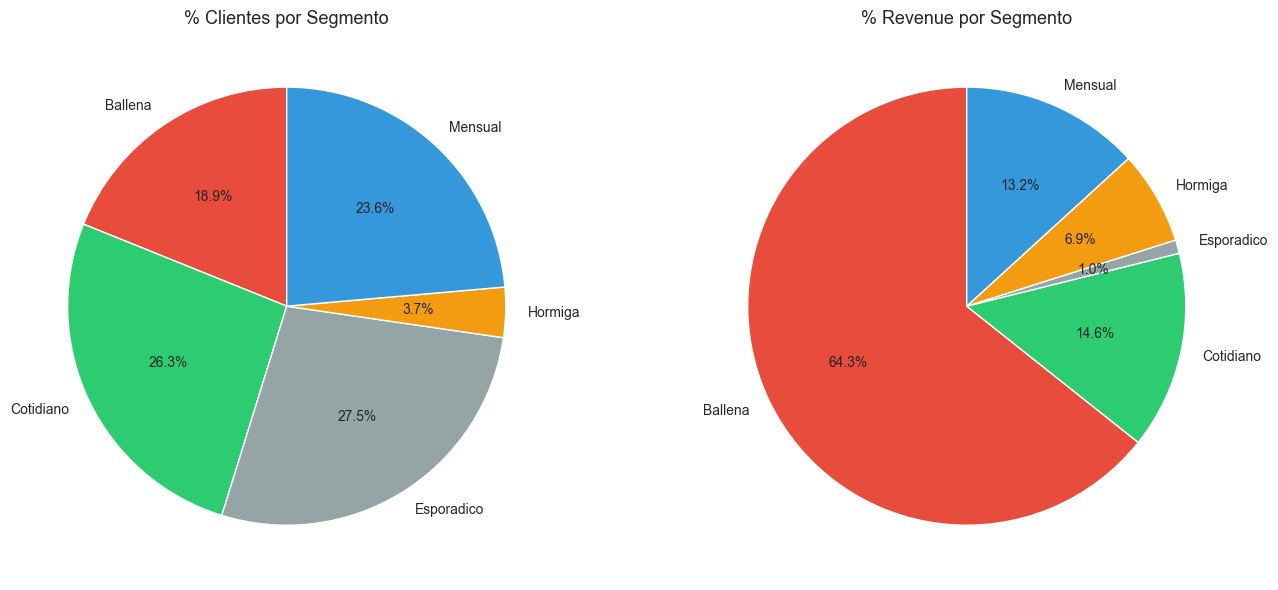

,clientes,revenue_total,pct_clientes,pct_revenue
segment,,,,
ballena,23620,3.121565e+12,18.9,64.3
cotidiano,32903,7.071144e+11,26.3,14.6
esporadico,34359,4.845637e+10,27.5,1.0
hormiga,4620,3.346421e+11,3.7,6.9
mensual,29508,6.418052e+11,23.6,13.2


In [11]:
# Composición: % clientes y % revenue por segmento
seg_summary = features.groupby("segment").agg(
    clientes=("id_client", "count"),
    revenue_total=("monetary_total", "sum"),
)
seg_summary["pct_clientes"] = seg_summary["clientes"] / seg_summary["clientes"].sum() * 100
seg_summary["pct_revenue"] = seg_summary["revenue_total"] / seg_summary["revenue_total"].sum() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = [SEGMENT_COLORS.get(s, "gray") for s in seg_summary.index]

ax1.pie(seg_summary["pct_clientes"], labels=seg_summary.index.str.title(),
        autopct="%1.1f%%", colors=colors, startangle=90)
ax1.set_title("% Clientes por Segmento", fontsize=13)

ax2.pie(seg_summary["pct_revenue"], labels=seg_summary.index.str.title(),
        autopct="%1.1f%%", colors=colors, startangle=90)
ax2.set_title("% Revenue por Segmento", fontsize=13)

plt.tight_layout()
plt.show()

display(seg_summary.round(1))

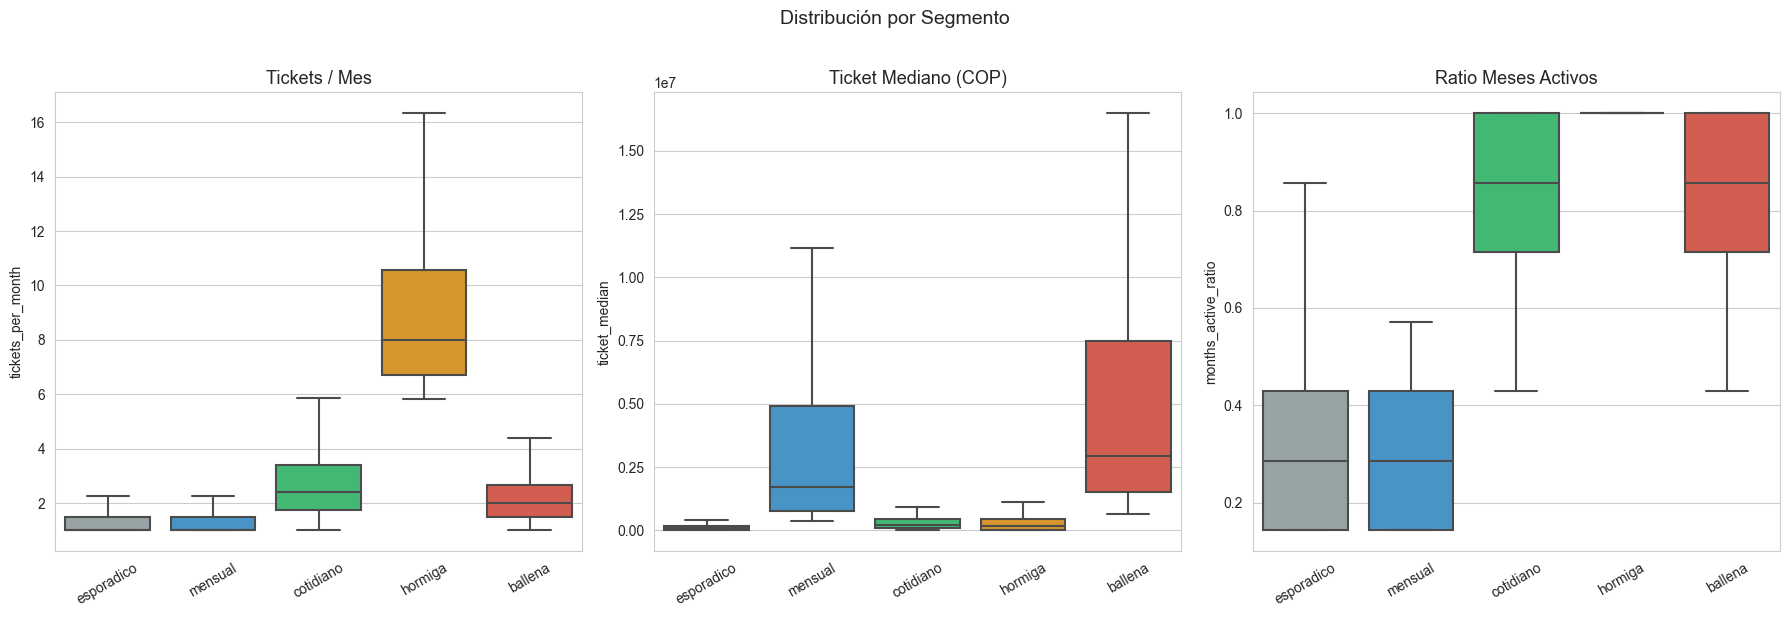

In [12]:
# Boxplots de las 3 features por segmento
order = ["esporadico", "mensual", "cotidiano", "hormiga", "ballena"]
order = [s for s in order if s in features["segment"].values]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title in zip(axes, 
    ["tickets_per_month", "ticket_median", "months_active_ratio"],
    ["Tickets / Mes", "Ticket Mediano (COP)", "Ratio Meses Activos"]):
    
    palette = {s: SEGMENT_COLORS[s] for s in order}
    sns.boxplot(data=features, x="segment", y=col, order=order,
                palette=palette, ax=ax, showfliers=False)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Distribución por Segmento", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Ciclo de Gasto Mensual por Segmento

Patrón de gasto por día del mes — muestra dependencia del ciclo de nómina.

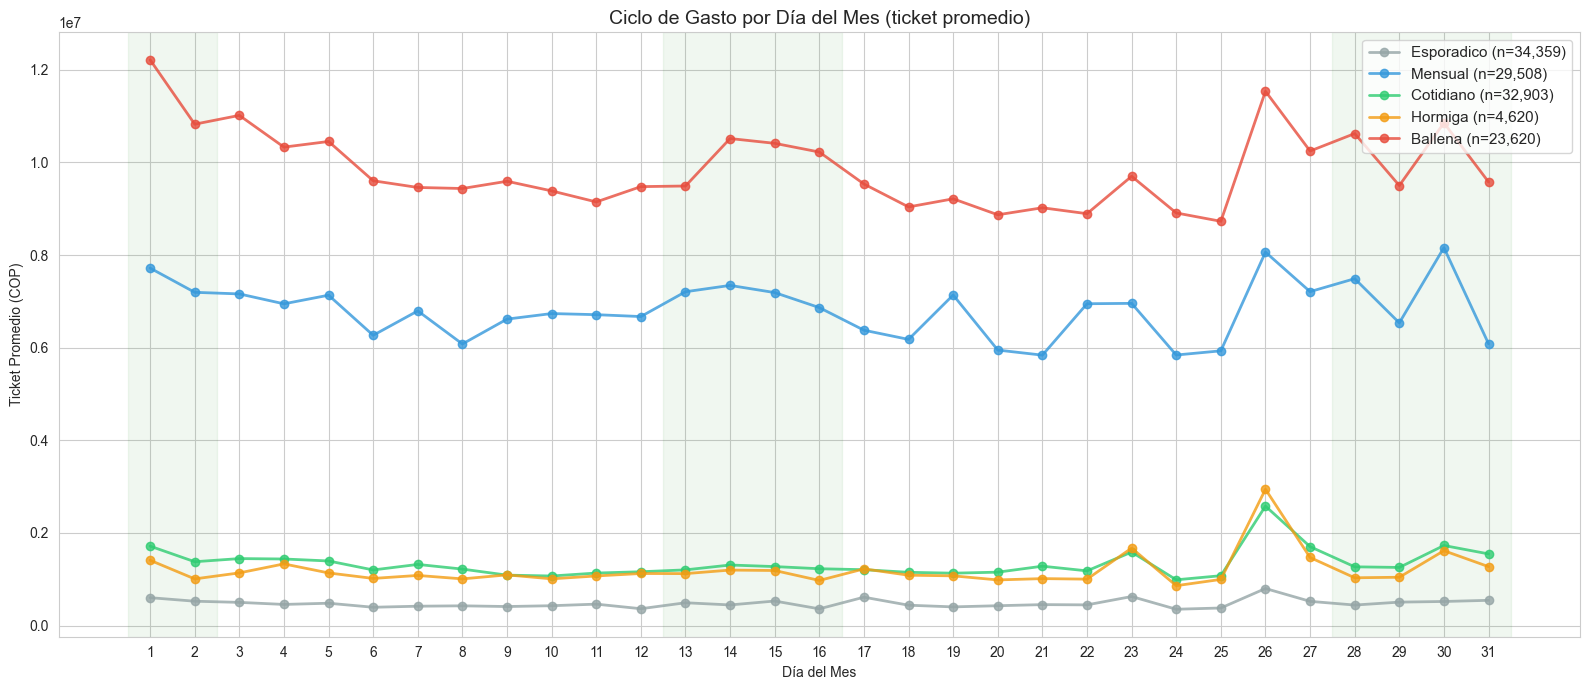

In [13]:
# Unir ventas con segmentos
sales_seg = recent.merge(
    features[["id_client", "segment"]],
    on="id_client", how="inner",
)

# Ticket por (cliente, fecha)
tickets = (
    sales_seg.groupby(["id_client", "date_sale", "segment"])
    .agg(ticket_value=("invoice_value_with_discount_and_without_iva", "sum"))
    .reset_index()
)
tickets["dia_mes"] = tickets["date_sale"].dt.day

# Gasto promedio por día del mes
gasto_dia = tickets.groupby(["segment", "dia_mes"])["ticket_value"].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 7))
for seg in ["esporadico", "mensual", "cotidiano", "hormiga", "ballena"]:
    data = gasto_dia[gasto_dia["segment"] == seg]
    if data.empty:
        continue
    n = len(features[features["segment"] == seg])
    ax.plot(data["dia_mes"], data["ticket_value"], marker="o", linewidth=2,
            color=SEGMENT_COLORS[seg], label=f"{seg.title()} (n={n:,})", alpha=0.8)

# Zonas de quincena
for x0, x1, lbl in [(0.5, 2.5, "Nómina"), (12.5, 16.5, "Quincena"), (27.5, 31.5, "Fin mes")]:
    ax.axvspan(x0, x1, color="green", alpha=0.06)

ax.set_title("Ciclo de Gasto por Día del Mes (ticket promedio)", fontsize=14)
ax.set_xlabel("Día del Mes")
ax.set_ylabel("Ticket Promedio (COP)")
ax.set_xticks(range(1, 32))
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 7. Productos Top por Segmento

Los 10 productos con mayor penetración (% de tickets que lo contienen) en cada segmento.

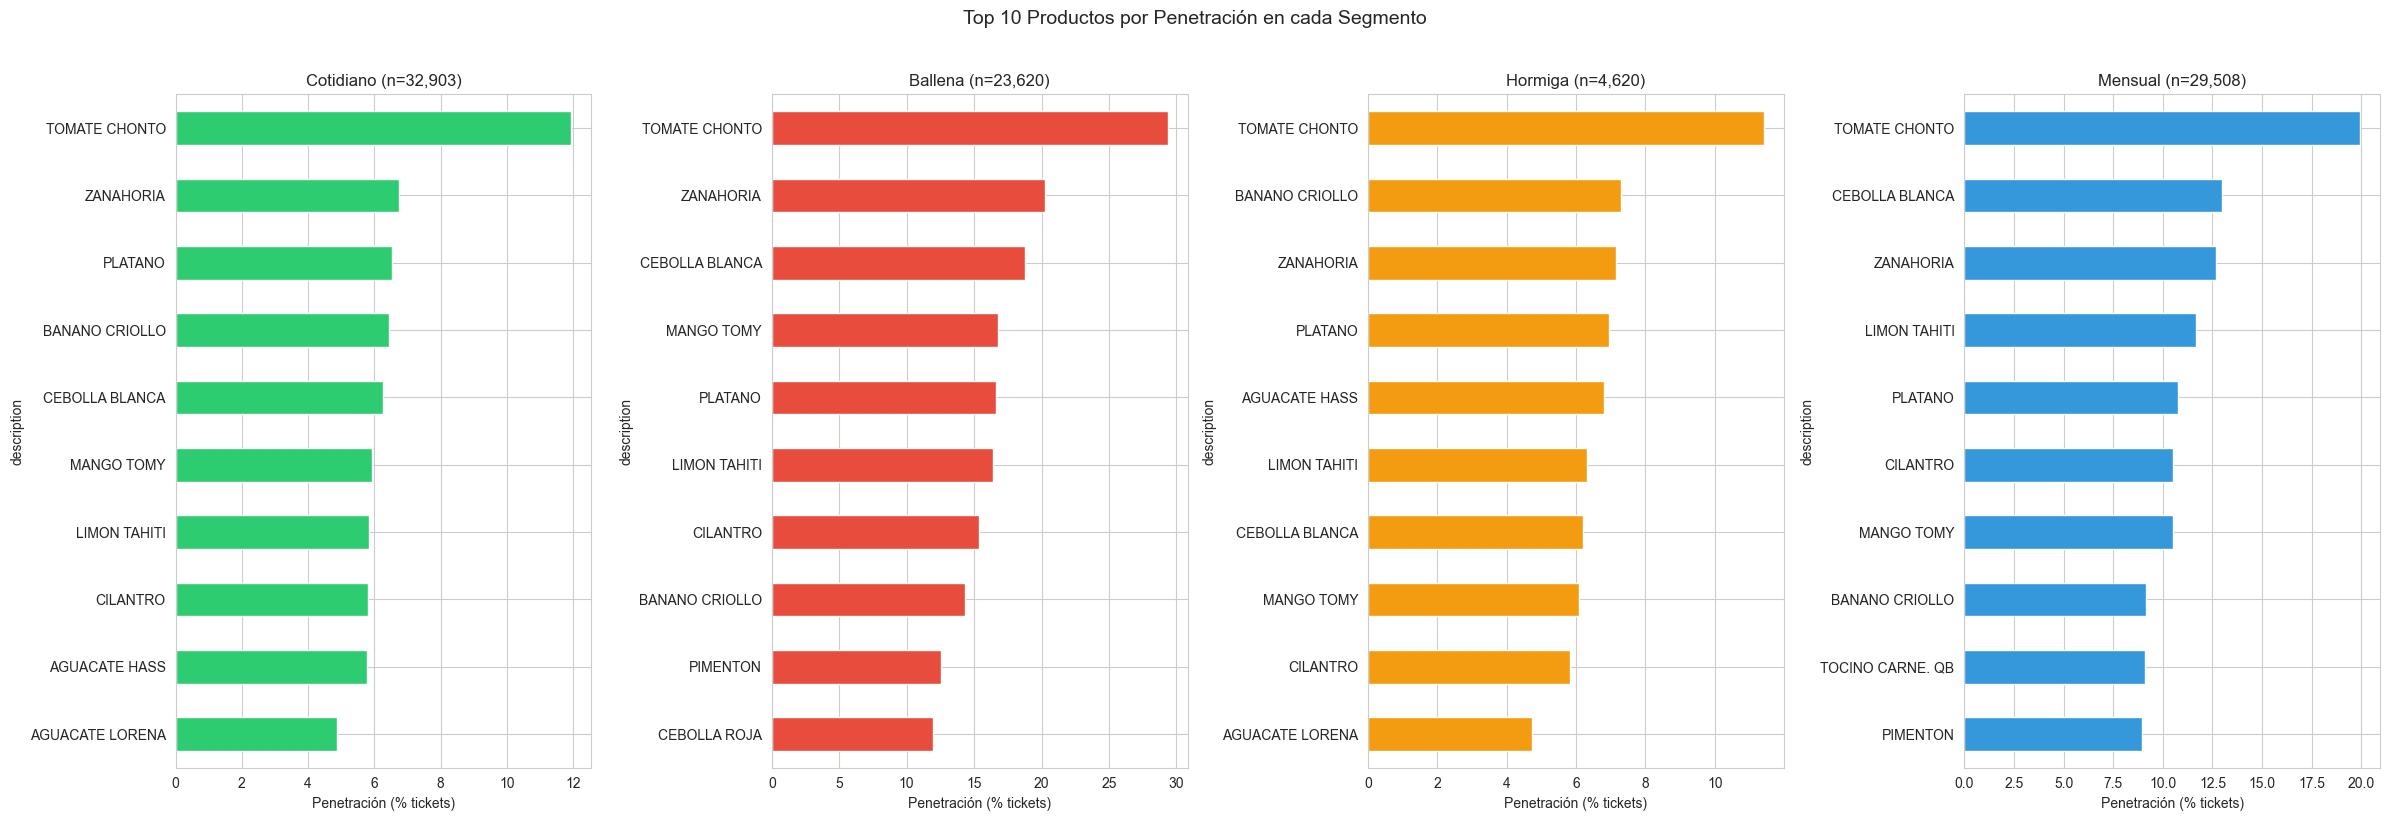

In [14]:
# Productos top por penetración en cada segmento
excluir = clust_cfg.get("excluded_product_descriptions", [])
sales_prods = sales_seg.merge(productos, on="product", how="left")
sales_prods = sales_prods[~sales_prods["description"].isin(excluir)].dropna(subset=["description"])

segments_to_plot = [s for s in ["cotidiano", "ballena", "hormiga", "mensual"]
                    if s in features["segment"].values]
n_plots = len(segments_to_plot)

fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 8), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, seg in zip(axes, segments_to_plot):
    seg_data = sales_prods[sales_prods["segment"] == seg]
    total_tickets = seg_data.groupby(["id_client", "date_sale"]).ngroups
    if total_tickets == 0:
        continue

    prod_counts = (
        seg_data.groupby("description")
        .apply(lambda g: g.groupby(["id_client", "date_sale"]).ngroups, include_groups=False)
        .sort_values(ascending=False)
        .head(10)
    )
    penetration = prod_counts / total_tickets * 100

    n_cl = len(features[features["segment"] == seg])
    penetration.plot.barh(ax=ax, color=SEGMENT_COLORS[seg])
    ax.set_title(f"{seg.title()} (n={n_cl:,})", fontsize=12)
    ax.set_xlabel("Penetración (% tickets)")
    ax.invert_yaxis()

fig.suptitle("Top 10 Productos por Penetración en cada Segmento", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Evolución Mensual

INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using ca

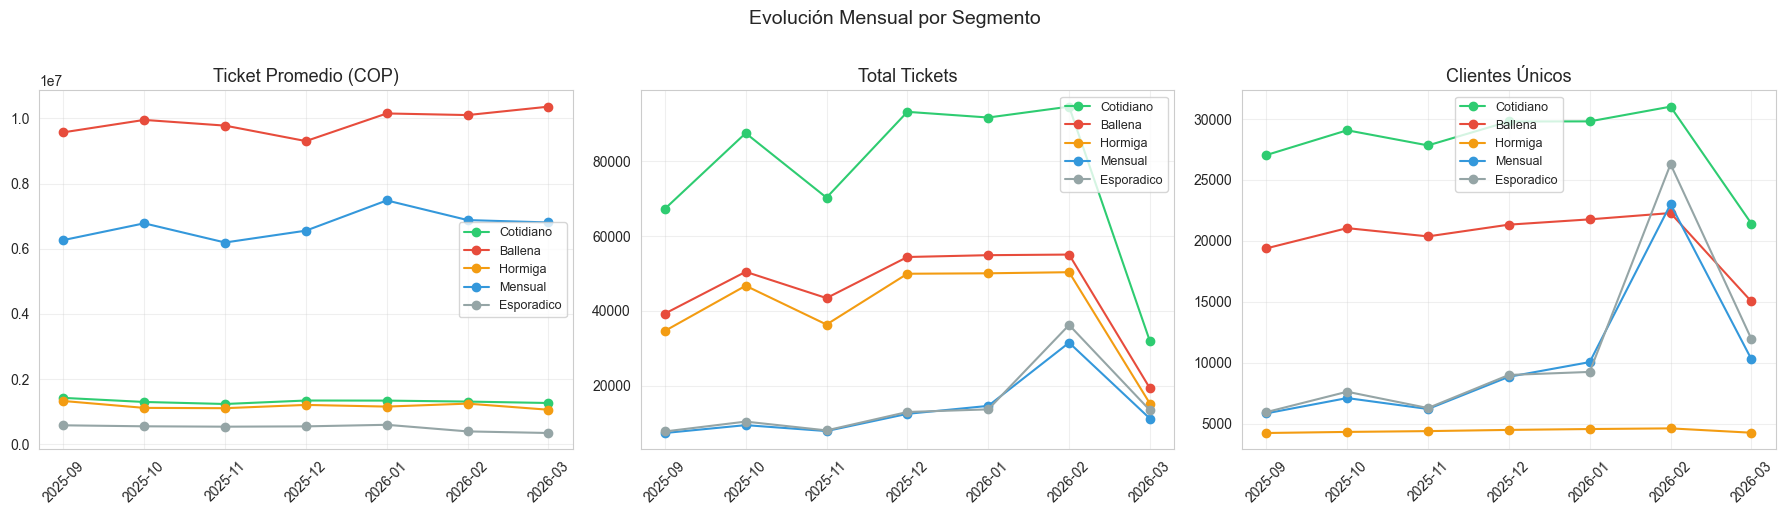

In [15]:
# Métricas mensuales por segmento
tickets["mes"] = tickets["date_sale"].dt.to_period("M")

monthly = tickets.groupby(["segment", "mes"]).agg(
    ticket_promedio=("ticket_value", "mean"),
    n_tickets=("ticket_value", "count"),
    clientes_unicos=("id_client", "nunique"),
).reset_index()
monthly["mes_str"] = monthly["mes"].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [
    ("ticket_promedio", "Ticket Promedio (COP)"),
    ("n_tickets", "Total Tickets"),
    ("clientes_unicos", "Clientes Únicos"),
]

for ax, (col, title) in zip(axes, metrics):
    for seg in ["cotidiano", "ballena", "hormiga", "mensual", "esporadico"]:
        data = monthly[monthly["segment"] == seg]
        if data.empty:
            continue
        ax.plot(data["mes_str"], data[col], marker="o",
                color=SEGMENT_COLORS[seg], label=seg.title())
    ax.set_title(title, fontsize=13)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Evolución Mensual por Segmento", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Clientes Válidos para Predicción

Los **esporádicos** no tienen patrón predecible. Los **ballenas** son mini-mercados con dinámica distinta.

Clientes **predecibles**: cotidianos + mensuales + hormigas.

In [16]:
# Segmentos válidos para el modelo de predicción
PREDICTABLE_SEGMENTS = {"cotidiano", "mensual", "hormiga"}

pred_mask = features["segment"].isin(PREDICTABLE_SEGMENTS)
n_total = len(features)
n_pred = pred_mask.sum()
n_excl = n_total - n_pred

print(f"Total clientes segmentados: {n_total:,}")
print(f"Válidos para predicción: {n_pred:,} ({n_pred/n_total*100:.1f}%)")
print(f"Excluidos (esporádico + ballena): {n_excl:,} ({n_excl/n_total*100:.1f}%)")

print("\nDetalle:")
for seg in sorted(features["segment"].unique()):
    n = (features["segment"] == seg).sum()
    status = "PREDICCIÓN" if seg in PREDICTABLE_SEGMENTS else "EXCLUIDO"
    print(f"  {seg:12s}: {n:>8,} clientes → {status}")

Total clientes segmentados: 125,010
Válidos para predicción: 67,031 (53.6%)
Excluidos (esporádico + ballena): 57,979 (46.4%)

Detalle:
  ballena     :   23,620 clientes → EXCLUIDO
  cotidiano   :   32,903 clientes → PREDICCIÓN
  esporadico  :   34,359 clientes → EXCLUIDO
  hormiga     :    4,620 clientes → PREDICCIÓN
  mensual     :   29,508 clientes → PREDICCIÓN


## 10. Exportación de Resultados

**Archivos generados:**
- `data/processed/cluster_assignments.parquet` — Segmento + features por cliente
- `data/processed/recommendations/precomputed_cluster_recs.parquet` — Recomendaciones por segmento

In [17]:
# Guardar asignaciones de segmento
output_cols = [
    "id_client", "cluster", "segment", "segment_label",
    "tickets_per_month", "ticket_median", "months_active_ratio",
    "products_per_visit", "product_distinct", "monetary_total",
]
df_output = features[output_cols].rename(columns={"id_client": "client"})

output_path = proc / "cluster_assignments.parquet"
save_parquet(df_output, output_path, "Asignaciones de segmento")

print(f"\nGuardado: {output_path}")
print(f"Total: {len(df_output):,} clientes")
print(df_output.groupby("segment").size().to_string())

INFO - Asignaciones de segmento guardado: 125010 filas en data/processed/cluster_assignments.parquet



Guardado: data/processed/cluster_assignments.parquet
Total: 125,010 clientes
segment
ballena       23620
cotidiano     32903
esporadico    34359
hormiga        4620
mensual       29508


In [18]:
# Recomendaciones por segmento
cluster_avg = features.groupby("cluster")["product_distinct"].mean()

recommendations = {}
for cid in sorted(features["cluster"].unique()):
    top_n = max(1, int(round(cluster_avg.get(cid, 5))))
    seg = features.loc[features["cluster"] == cid, "segment"].iloc[0]
    cluster_sales = sales_prods[sales_prods["segment"] == seg]
    top_products = (
        cluster_sales["description"].value_counts()
        .nlargest(top_n).index.tolist()
    )
    recommendations[cid] = top_products
    print(f"Cluster {cid} ({seg}): {len(top_products)} productos")

df_recs = features[["id_client", "cluster", "segment", "segment_label"]].copy()
df_recs["recommended_products"] = df_recs["cluster"].map(recommendations)
df_recs = df_recs.rename(columns={"id_client": "client", "cluster": "purchase_pattern_cluster"})

recs_path = proc / clust_cfg["output_folder"] / clust_cfg["precomputed_cluster_recs_file"]
save_parquet(df_recs, recs_path, "Recomendaciones por segmento")
print(f"\nGuardado: {recs_path}")

Cluster 0 (cotidiano): 75 productos
Cluster 1 (ballena): 158 productos
Cluster 2 (hormiga): 181 productos
Cluster 3 (mensual): 45 productos
Cluster 4 (esporadico): 11 productos


INFO - Recomendaciones por segmento guardado: 125010 filas en data/processed/recommendations/precomputed_cluster_recs.parquet



Guardado: data/processed/recommendations/precomputed_cluster_recs.parquet


## 11. Resumen y Siguientes Pasos

### Archivos generados
- `data/processed/cluster_assignments.parquet` — Cliente → segmento + features
- `data/processed/recommendations/precomputed_cluster_recs.parquet` — Recomendaciones por segmento

### Uso en producción
```bash
uv run python src/train_recommender_by_clustering.py --config params.yaml
```

### Segmentos para predicción
- **Incluir:** Cotidiano, Mensual, Hormiga (patrones predecibles)
- **Excluir:** Esporádico (irregular), Ballena (mini-mercado, dinámica B2B)

### Estrategias de marketing por segmento
- **Cotidiano** → Cross-sell, subir ticket con combos
- **Mensual** → Incentivar segunda visita del mes
- **Hormiga** → Subir ticket por visita, productos complementarios
- **Ballena** → Programa VIP, descuentos por volumen
- **Esporádico** → Campañas de reactivación